# LeXi: Context-Based Vocabulary Learning Agent

`LeXi`는 `Lexicon`에서 이름을 가져온 영어 기술 문서 학습 에이전트다.

## Step 1. Agent Design

- **Theme**: Education & Learning
- **Purpose**: 영어 기술 문장이나 문단에서 학습이 필요한 핵심 단어를 추출하고, 문맥 기반 뜻과 출처를 구조화한다.
- **Key Features**:
  - 학습 가치가 높은 단어 후보 추출
  - 문맥 기반 뜻 정리
  - 단어장 엔트리 구조화

```mermaid
flowchart TD
    A[User Input: English technical sentence or paragraph]
    B[Node 1: Extract learning-worthy words]
    C[Node 2: Build context-based vocabulary entries]
    D[Notebook Output: Structured vocabulary list]

    E[(Future) Vocabulary storage]
    F[(Future) Search words and trace sources]
    G[(Future) Frequency analysis and study priority]
    H[(Future) Review and quiz generation]

    A --> B --> C --> D
    C -. future .-> E
    E -. future .-> F
    E -. future .-> G
    G -. future .-> H
```

이번 단계에서는 실선 흐름만 구현한다. 저장, 검색, 통계, 퀴즈 기능은 향후 확장 범위다.


In [1]:
from __future__ import annotations

import re
from pprint import pprint
from typing import TypedDict

from langgraph.graph import END, START, StateGraph


In [2]:
class VocabularyEntry(TypedDict):
    word: str
    lemma: str
    meaning_in_context: str
    source_sentence: str
    context_note: str
    reason_to_learn: str


class LearningState(TypedDict):
    input_text: str
    sentences: list[str]
    candidate_words: list[str]
    vocabulary_entries: list[VocabularyEntry]


In [3]:
STOPWORDS = {
    'a', 'an', 'and', 'are', 'as', 'at', 'be', 'but', 'by', 'can', 'for', 'from',
    'if', 'in', 'into', 'is', 'it', 'of', 'on', 'or', 'so', 'that', 'the', 'their',
    'then', 'there', 'this', 'to', 'when', 'while', 'with', 'your', 'must', 'remain',
    'helps', 'help', 'using', 'used', 'than', 'such', 'will', 'after', 'before'
}

TECH_HINT_WORDS = {
    'api', 'async', 'asynchronous', 'backend', 'cache', 'caching', 'client', 'cluster',
    'compatibility', 'configuration', 'container', 'dataset', 'dependency', 'endpoint',
    'failure', 'frontend', 'invalid', 'invalidation', 'latency', 'mechanism', 'payload',
    'protocol', 'response', 'responses', 'retry', 'schema', 'serialize', 'serializes',
    'serialization', 'server', 'throughput', 'transient', 'validation'
}

MEANING_HINTS = {
    'api': '애플리케이션이 서로 통신하기 위한 인터페이스',
    'cache': '이전 계산 결과를 임시로 저장해 재사용하는 저장 공간',
    'caching': '자주 필요한 데이터를 임시 저장해 성능을 높이는 방식',
    'compatibility': '기존 버전이나 다른 시스템과 함께 동작할 수 있는 성질',
    'invalidation': '캐시된 데이터가 더 이상 유효하지 않음을 표시하는 과정',
    'latency': '요청과 응답 사이에 걸리는 지연 시간',
    'mechanism': '특정 동작을 수행하게 하는 방식 또는 구조',
    'response': '시스템이 요청에 대해 돌려주는 결과',
    'responses': '시스템이 요청들에 대해 돌려주는 결과들',
    'retry': '실패한 작업을 다시 시도하는 동작',
    'schema': '데이터 구조와 필드를 정의한 형식 규칙',
    'serialization': '데이터를 전송 또는 저장 가능한 형식으로 바꾸는 과정',
    'serializes': '데이터를 전송 또는 저장 가능한 형식으로 변환한다는 의미',
    'throughput': '단위 시간 동안 처리할 수 있는 작업량',
    'transient': '잠시 발생했다가 사라질 수 있는 일시적인 상태'
}


def split_sentences(text: str) -> list[str]:
    normalized = re.sub(r'\s+', ' ', text).strip()
    if not normalized:
        return []
    return [sentence.strip() for sentence in re.split(r'(?<=[.!?])\s+', normalized) if sentence.strip()]


def extract_tokens(sentence: str) -> list[str]:
    return re.findall(r"[A-Za-z][A-Za-z-]*", sentence)


def simple_lemma(word: str) -> str:
    lower = word.lower()
    if lower.endswith('ies') and len(lower) > 4:
        return lower[:-3] + 'y'
    if lower.endswith('ing') and len(lower) > 5:
        stem = lower[:-3]
        if stem + 'e' in TECH_HINT_WORDS or stem + 'e' in MEANING_HINTS:
            return stem + 'e'
        if len(stem) >= 2 and stem[-1] == stem[-2] and stem[-1] not in 'aeiou':
            return stem[:-1]
        return stem
    if lower.endswith('ed') and len(lower) > 4:
        stem = lower[:-2]
        if stem + 'e' in TECH_HINT_WORDS or stem + 'e' in MEANING_HINTS:
            return stem + 'e'
        return stem
    if lower.endswith('s') and len(lower) > 4 and not lower.endswith('ss'):
        return lower[:-1]
    return lower


def score_candidate(token: str) -> int:
    lower = token.lower()
    if lower in STOPWORDS or len(lower) < 4:
        return 0

    score = 0
    if lower in TECH_HINT_WORDS:
        score += 3
    if len(lower) >= 8:
        score += 1
    if lower.endswith(('tion', 'sion', 'ment', 'ance', 'ence', 'ity', 'able', 'ible')):
        score += 1
    return score


def infer_meaning(word: str) -> str:
    lower = word.lower()
    if lower in MEANING_HINTS:
        return MEANING_HINTS[lower]
    if lower.endswith(('tion', 'sion')):
        return '어떤 처리 과정이나 변환 절차를 가리키는 기술 용어'
    if lower.endswith(('ity', 'ance', 'ence')):
        return '시스템의 상태나 성질을 설명하는 기술 용어'
    if lower.endswith(('able', 'ible')):
        return '가능성이나 특성을 설명하는 표현'
    return '문맥상 중요한 기술 개념 또는 동작을 나타내는 표현'


def infer_reason_to_learn(word: str) -> str:
    lower = word.lower()
    if lower in TECH_HINT_WORDS:
        return '기술 문서, API 설명, 시스템 설계 문맥에서 자주 등장할 가능성이 높다.'
    if len(lower) >= 8:
        return '형태가 길고 추상도가 높아 초급 학습자가 의미를 놓치기 쉽다.'
    return '문맥 이해와 재등장 추적에 도움이 되는 핵심 어휘다.'


def extract_candidates(state: LearningState) -> LearningState:
    text = state['input_text']
    sentences = split_sentences(text)
    if not sentences:
        return {
            'sentences': [],
            'candidate_words': [],
            'vocabulary_entries': []
        }

    scored_words: dict[str, tuple[str, int]] = {}
    order: list[str] = []

    for sentence in sentences:
        for token in extract_tokens(sentence):
            normalized = token.lower()
            score = score_candidate(token)
            if score == 0:
                continue
            if normalized not in scored_words:
                scored_words[normalized] = (token, score)
                order.append(normalized)
            else:
                first_seen, best_score = scored_words[normalized]
                scored_words[normalized] = (first_seen, max(best_score, score))

    ranked = sorted(order, key=lambda word: (-scored_words[word][1], order.index(word)))
    candidates = ranked[:8]

    return {
        'sentences': sentences,
        'candidate_words': candidates,
        'vocabulary_entries': []
    }


def build_vocabulary_entries(state: LearningState) -> LearningState:
    sentences = state.get('sentences', [])
    candidate_words = state.get('candidate_words', [])
    if not sentences or not candidate_words:
        return {'vocabulary_entries': []}

    entries: list[VocabularyEntry] = []

    for candidate in candidate_words:
        source_sentence = next(
            (sentence for sentence in sentences if re.search(rf'\b{re.escape(candidate)}\b', sentence, re.IGNORECASE)),
            sentences[0],
        )
        matched_word = next(
            (token for token in extract_tokens(source_sentence) if token.lower() == candidate),
            candidate,
        )
        lemma = simple_lemma(matched_word)
        meaning = infer_meaning(matched_word)
        context_note = (
            f"이 문장에서는 '{matched_word}'가 시스템 동작이나 데이터 처리 방식을 설명하는 핵심 표현으로 사용된다."
        )

        entries.append(
            {
                'word': matched_word,
                'lemma': lemma,
                'meaning_in_context': meaning,
                'source_sentence': source_sentence,
                'context_note': context_note,
                'reason_to_learn': infer_reason_to_learn(matched_word),
            }
        )

    return {'vocabulary_entries': entries}


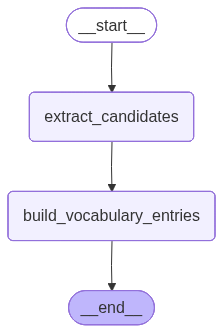

In [4]:
graph_builder = StateGraph(LearningState)
graph_builder.add_node('extract_candidates', extract_candidates)
graph_builder.add_node('build_vocabulary_entries', build_vocabulary_entries)

graph_builder.add_edge(START, 'extract_candidates')
graph_builder.add_edge('extract_candidates', 'build_vocabulary_entries')
graph_builder.add_edge('build_vocabulary_entries', END)

lexi_graph = graph_builder.compile()
lexi_graph


In [5]:
sample_input = {
    'input_text': (
        'Caching reduces latency, but inconsistent invalidation can cause stale data. '
        'When the API serializes responses, the schema must remain stable for backward compatibility. '
        'A retry mechanism helps the client recover from transient failures.'
    ),
    'sentences': [],
    'candidate_words': [],
    'vocabulary_entries': [],
}

result = lexi_graph.invoke(sample_input)
pprint(result)


{'candidate_words': ['invalidation',
                     'compatibility',
                     'serializes',
                     'responses',
                     'mechanism',
                     'transient',
                     'caching',
                     'latency'],
 'input_text': 'Caching reduces latency, but inconsistent invalidation can '
               'cause stale data. When the API serializes responses, the '
               'schema must remain stable for backward compatibility. A retry '
               'mechanism helps the client recover from transient failures.',
 'sentences': ['Caching reduces latency, but inconsistent invalidation can '
               'cause stale data.',
               'When the API serializes responses, the schema must remain '
               'stable for backward compatibility.',
               'A retry mechanism helps the client recover from transient '
               'failures.'],
 'vocabulary_entries': [{'context_note': "이 문장에서는 'invalidation'가 